# NER with BERT: feature-based adaptation and full fine-tuning

Adapt **bert-base-cased** (110M) to CoNLL-2003 (`lhoestq/conll2003`) with two methods, the same data, the same seed, and the same metric (entity-level F1 from seqeval):

1. **Feature-based.** The BERT body stays frozen and in eval mode (no dropout). Only a linear head trains.
2. **Full fine-tuning.** The body and the head both train, with separate learning rates.

**Hypothesis.** NER depends on each token's context, so full fine-tuning should beat frozen features. If the F1 gap is within 1–3 points, that is seed noise, not a finding.

`bert-base-uncased` exists on Hugging Face, but NER uses the **cased** variant: the dataset is case-sensitive, and the uncased tokenizer lowercases everything. There is nothing to deploy. `from_pretrained("bert-base-cased")` downloads the tokenizer and the weights into the Hugging Face cache.


## 1. Environment

Install what is needed to load the data, tokenize, and train. The device is printed so training goes to GPU, MPS, or CPU. On CPU, full fine-tuning of 110M parameters is slow; this notebook runs on Colab without changing the logic.


In [ ]:
import importlib.util
import subprocess
import sys

needed = []
for module, package in [
    ("torch", "torch"),
    ("transformers", "transformers>=4.46.0"),
    ("datasets", "datasets>=3.0.0"),
    ("seqeval", "seqeval>=1.2.2"),
    ("accelerate", "accelerate>=1.0.0"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
]:
    if importlib.util.find_spec(module) is None:
        needed.append(package)
if needed:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *needed])


In [ ]:
import gc
import inspect
import os
import random
import time

import numpy as np
import torch

# Let MPS fall back to CPU for the few ops it does not implement, instead of crashing.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
# Rust tokenizers use multiple threads during dataset.map (see the tokenize cell).
os.environ.setdefault("TOKENIZERS_PARALLELISM", "true")

from datasets import load_dataset
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from torch.optim import AdamW
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

SEED = 42
MODEL_NAME = "bert-base-cased"
MAX_LENGTH = 128
BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32          # no gradients at eval, so a larger batch is fine
GRAD_ACCUM = 1               # raise to 2 to halve memory while keeping the effective batch
NUM_EPOCHS = 3
HEAD_LR = 1e-3
BERT_LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


NUM_WORKERS = 0 if device.type == "mps" else min(4, os.cpu_count() or 1)
# Cap tokenization processes; the dataset is small, so a few processes are plenty.
MAP_PROCS = min(4, os.cpu_count() or 1)
torch.set_num_threads(min(8, os.cpu_count() or 1))


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def free_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()


set_seed(SEED)
print(f"device={device}  workers={NUM_WORKERS}  map_procs={MAP_PROCS}  seed={SEED}")


device=mps  workers=0  map_procs=4  seed=42


## 2. Data

CoNLL-2003 has one label per word. The 9 classes are `O` and the BIO pairs for PER, ORG, LOC, and MISC. This copy stores `ner_tags` as integers, not as a `ClassLabel`, so the names are the standard CoNLL order.


In [12]:
dataset = load_dataset("lhoestq/conll2003", cache_dir="./data_cache")
label_names = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-MISC",
    "I-MISC",
]
id2label = {index: name for index, name in enumerate(label_names)}
label2id = {name: index for index, name in enumerate(label_names)}
unknown = sorted({tag for row in dataset["train"]["ner_tags"] for tag in row if tag not in id2label})
if unknown:
    raise ValueError(f"Unexpected ner tag ids: {unknown}")

print(dataset)
print("labels:", label_names)
example = dataset["train"][0]
print("tokens:", example["tokens"])
print("ner:   ", [label_names[i] for i in example["ner_tags"]])


DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
ner:    ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


## 3. Tokenizer

The fast tokenizer is required because `word_ids()` tells which word each subword belongs to. The slow Python tokenizer does not have that method.


In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if not tokenizer.is_fast:
    raise RuntimeError("The fast tokenizer is required for word_ids().")
print(tokenizer.__class__.__name__, "vocab", tokenizer.vocab_size)


BertTokenizerFast vocab 28996


## 4. Subword alignment

The tokenizer splits some words (`playing` may become `play` + `##ing`), but the dataset has one label per word. The label goes on the **first subword**. Continuation pieces `##`, `[CLS]`, `[SEP]`, and padding get `-100`, the index `CrossEntropyLoss` ignores.


In [14]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=MAX_LENGTH,
    )
    aligned = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous:
                label_ids.append(-100)
            else:
                label_ids.append(labels[word_idx])
            previous = word_idx
        if len(label_ids) != len(tokenized["input_ids"][i]):
            raise ValueError("Labels do not match the tokens.")
        aligned.append(label_ids)
    tokenized["labels"] = aligned
    return tokenized


# batched=True lets the Rust tokenizer work on many rows at once; num_proc splits the
# splits across processes. remove_columns drops the raw text so the cached arrays stay small.
tokenized = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    num_proc=MAP_PROCS if MAP_PROCS > 1 else None,
    remove_columns=dataset["train"].column_names,
)
print({split: len(tokenized[split]) for split in tokenized})


Setting TOKENIZERS_PARALLELISM=false for forked processes.
Map (num_proc=4): 100%|██████████| 14041/14041 [00:00<00:00, 24177.90 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Map (num_proc=4): 100%|██████████| 3250/3250 [00:00<00:00, 20969.49 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Map (num_proc=4): 100%|██████████| 3453/3453 [00:00<00:00, 21827.95 examples/s]

{'train': 14041, 'validation': 3250, 'test': 3453}


## 5. Sanity check

One batch with each token next to its label. `-100` should appear on `[CLS]`, `[SEP]`, `##` continuations, and padding.


In [15]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
model_columns = ["input_ids", "attention_mask", "labels"]
if "token_type_ids" in tokenized["train"].column_names:
    model_columns.append("token_type_ids")

features = [
    {key: tokenized["train"][i][key] for key in model_columns}
    for i in range(2)
]
batch = data_collator(features)
assert batch["input_ids"].shape == batch["labels"].shape

print(f"{'token':<16}{'label':<10}")
for token_id, label_id in zip(batch["input_ids"][0].tolist(), batch["labels"][0].tolist()):
    token = tokenizer.convert_ids_to_tokens(token_id)
    label = label_names[label_id] if label_id != -100 else "-100"
    print(f"{token:<16}{label:<10}")


token           label     
[CLS]           -100      
EU              B-ORG     
rejects         O         
German          B-MISC    
call            O         
to              O         
boycott         O         
British         B-MISC    
la              O         
##mb            -100      
.               O         
[SEP]           -100      


## 6. Metric

The metric that decides is CoNLL **entity-level F1** (seqeval): precision and recall over the whole span, not over each token. Token accuracy is logged for debugging and does not choose the model, because the `O` class dominates it. Training watches `validation`. `test` is reported once, at the end.


In [16]:
def align_predictions(predictions, label_ids):
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    pred_ids = np.argmax(predictions, axis=-1)
    batch_preds, batch_labels = [], []
    for pred_row, label_row in zip(pred_ids, label_ids):
        true_preds, true_labels = [], []
        for pred, label in zip(pred_row, label_row):
            if label == -100:
                continue
            true_preds.append(label_names[int(pred)])
            true_labels.append(label_names[int(label)])
        batch_preds.append(true_preds)
        batch_labels.append(true_labels)
    return batch_preds, batch_labels


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    preds, refs = align_predictions(predictions, labels)
    pred_ids = np.argmax(predictions, axis=-1)
    mask = labels != -100
    token_accuracy = float((pred_ids[mask] == labels[mask]).mean())
    return {
        "precision": precision_score(refs, preds),
        "recall": recall_score(refs, preds),
        "f1": f1_score(refs, preds),
        "token_accuracy": token_accuracy,
    }


## 7. Shared training setup

Both methods share the batch size, the number of epochs, the seed, and the collator. They differ in which parameters receive gradients and in the learning rate.

- A freshly initialized head wants `1e-3`.
- The pretrained body, only in full fine-tuning, wants `2e-5`. A single learning rate for both quietly damages the comparison.

In the feature-based run the encoder stays in `eval` during the training step so dropout does not change the features.


In [17]:
def count_trainable(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def make_training_args(output_dir: str) -> TrainingArguments:
    field_names = set(getattr(TrainingArguments, "__dataclass_fields__", {}))
    kwargs = dict(
        output_dir=output_dir,
        save_strategy="epoch",
        learning_rate=HEAD_LR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        logging_steps=50,
        seed=SEED,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        dataloader_pin_memory=torch.cuda.is_available(),
        overwrite_output_dir=True,
    )
    # Feed the model from worker processes when it is safe (CUDA/CPU, not MPS).
    if "dataloader_num_workers" in field_names:
        kwargs["dataloader_num_workers"] = NUM_WORKERS
    if "dataloader_persistent_workers" in field_names and NUM_WORKERS > 0:
        kwargs["dataloader_persistent_workers"] = True
    # Move eval predictions off the accelerator in chunks so RAM does not balloon.
    if "eval_accumulation_steps" in field_names:
        kwargs["eval_accumulation_steps"] = 50
    if "eval_strategy" in field_names:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"
    if "data_seed" in field_names:
        kwargs["data_seed"] = SEED
    return TrainingArguments(**kwargs)


class TwoGroupTrainer(Trainer):
    """AdamW with one learning rate for the body and another for the head."""

    def __init__(self, *args, freeze_bert=False, bert_lr=BERT_LR, head_lr=HEAD_LR, **kwargs):
        super().__init__(*args, **kwargs)
        self.freeze_bert = freeze_bert
        self.bert_lr = bert_lr
        self.head_lr = head_lr

    def create_optimizer(self):
        if self.optimizer is not None:
            return self.optimizer

        def groups(named_params, lr):
            decay, no_decay = [], []
            for name, param in named_params:
                if not param.requires_grad:
                    continue
                if name.endswith("bias") or "LayerNorm" in name or "layer_norm" in name:
                    no_decay.append(param)
                else:
                    decay.append(param)
            grouped = []
            if decay:
                grouped.append({"params": decay, "lr": lr, "weight_decay": WEIGHT_DECAY})
            if no_decay:
                grouped.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})
            return grouped

        param_groups = groups(self.model.bert.named_parameters(), self.bert_lr)
        param_groups += groups(self.model.classifier.named_parameters(), self.head_lr)
        if not param_groups:
            raise RuntimeError("There are no trainable parameters.")
        self.optimizer = AdamW(param_groups)
        return self.optimizer

    def training_step(self, model, inputs, *args, **kwargs):
        if self.freeze_bert:
            model.bert.eval()
        return super().training_step(model, inputs, *args, **kwargs)


def build_model(freeze_bert: bool):
    set_seed(SEED)
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    if freeze_bert:
        for param in model.bert.parameters():
            param.requires_grad = False
    return model


def run_experiment(name: str, freeze_bert: bool):
    free_memory()
    model = build_model(freeze_bert)
    trainable = count_trainable(model)
    bert_trainable = sum(parameter.numel() for parameter in model.bert.parameters() if parameter.requires_grad)
    print(f"{name}: trainable={trainable:,}  bert_trainable={bert_trainable:,}")

    trainer_kwargs = dict(
        model=model,
        args=make_training_args(f"./outputs/{name}"),
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        freeze_bert=freeze_bert,
        bert_lr=BERT_LR,
        head_lr=HEAD_LR,
    )
    init_params = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in init_params:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    trainer = TwoGroupTrainer(**trainer_kwargs)

    started = time.perf_counter()
    train_result = trainer.train()
    elapsed = time.perf_counter() - started
    test_preds = trainer.predict(tokenized["test"], metric_key_prefix="test")
    test_metrics = test_preds.metrics
    pred_tags, true_tags = align_predictions(test_preds.predictions, test_preds.label_ids)
    print(classification_report(true_tags, pred_tags, digits=4))

    row = {
        "method": name,
        "precision": test_metrics["test_precision"],
        "recall": test_metrics["test_recall"],
        "f1": test_metrics["test_f1"],
        "token_accuracy": test_metrics["test_token_accuracy"],
        "train_loss": train_result.metrics["train_loss"],
        "test_loss": test_metrics["test_loss"],
        "seconds_per_epoch": elapsed / NUM_EPOCHS,
        "seconds_per_step": train_result.metrics["train_runtime"] / trainer.state.global_step,
        "trainable_params": trainable,
        "bert_trainable_params": bert_trainable,
    }

    # Drop the optimizer (AdamW keeps two moments per weight ~ heavy for full fine-tuning).
    # save_model only needs the weights, so free that RAM before the next run.
    trainer.optimizer = None
    del test_preds, train_result
    free_memory()
    return row, trainer


## 8. Feature-based adaptation

Nothing in the BERT body trains. The linear head consumes the last hidden state. Head learning rate: `1e-3`. Trainable BERT parameters: 0.


In [18]:
feature_row, feature_trainer = run_experiment("feature_based", freeze_bert=True)
feature_row


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


feature_based: trainable=6,921  bert_trainable=0


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Token Accuracy
1,0.150300,0.142777,0.803535,0.804077,0.803806,0.965707
2,0.116400,0.121841,0.808681,0.831705,0.820032,0.970851
3,0.123300,0.117549,0.820059,0.842992,0.831367,0.972352


              precision    recall  f1-score   support

         LOC     0.7744    0.8343    0.8032      1666
        MISC     0.7202    0.6638    0.6909       702
         ORG     0.6865    0.7381    0.7113      1661
         PER     0.9398    0.9176    0.9286      1615

   micro avg     0.7862    0.8086    0.7973      5644
   macro avg     0.7802    0.7885    0.7835      5644
weighted avg     0.7891    0.8086    0.7981      5644



{'method': 'feature_based',
 'precision': 0.7862187769164514,
 'recall': 0.8086463501063076,
 'f1': 0.7972748711677876,
 'token_accuracy': 0.9648835555938557,
 'train_loss': 0.21628885841224804,
 'test_loss': 0.1425890475511551,
 'seconds_per_epoch': 76.16783886133332,
 'seconds_per_step': 0.08672414578587699,
 'trainable_params': 6921,
 'bert_trainable_params': 0}

## 9. Full fine-tuning

The ~110M parameters of the body and the head all train. The body uses `2e-5` so pretraining is not wiped out. The freshly initialized head uses `1e-3`.


In [19]:
full_row, full_trainer = run_experiment("full_finetune", freeze_bert=False)
full_row


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


full_finetune: trainable=107,726,601  bert_trainable=107,719,680


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Token Accuracy
1,0.043600,0.039919,0.920020,0.932109,0.926025,0.988231
2,0.018000,0.036107,0.940281,0.946934,0.943596,0.990589
3,0.011600,0.036761,0.942633,0.949461,0.946034,0.991037


              precision    recall  f1-score   support

         LOC     0.9310    0.9316    0.9313      1666
        MISC     0.7864    0.8234    0.8045       702
         ORG     0.8750    0.9103    0.8923      1661
         PER     0.9637    0.9536    0.9586      1615

   micro avg     0.9047    0.9181    0.9114      5644
   macro avg     0.8890    0.9047    0.8967      5644
weighted avg     0.9059    0.9181    0.9119      5644



{'method': 'full_finetune',
 'precision': 0.9046787709497207,
 'recall': 0.9181431608788093,
 'f1': 0.9113612381287371,
 'token_accuracy': 0.982700303768016,
 'train_loss': 0.0816274690600897,
 'test_loss': 0.11523590981960297,
 'seconds_per_epoch': 311.05975800000004,
 'seconds_per_step': 0.35424764616552773,
 'trainable_params': 107726601,
 'bert_trainable_params': 107719680}

## 10. Comparison and delivered model

The delivered method is the one with the higher entity F1 on test. A gap of 3 points or less is recorded as noise from a single run. The loser stays documented here and is not saved for publication.


In [20]:
results = [feature_row, full_row]
headers = [
    "method",
    "precision",
    "recall",
    "f1",
    "train_loss",
    "test_loss",
    "seconds_per_epoch",
    "seconds_per_step",
    "trainable_params",
    "bert_trainable_params",
]


def format_cell(key, value):
    if isinstance(value, float):
        if key.startswith("seconds") or key.endswith("loss"):
            return f"{value:.2f}"
        return f"{value:.4f}"
    if isinstance(value, int):
        return f"{value:,}"
    return str(value)


lines = [
    "| " + " | ".join(headers) + " |",
    "| " + " | ".join("---" for _ in headers) + " |",
]
for row in results:
    lines.append("| " + " | ".join(format_cell(key, row[key]) for key in headers) + " |")
table = "\n".join(lines)
print(table)

gap = abs(feature_row["f1"] - full_row["f1"])
if gap <= 0.03:
    print(
        f"F1 gap = {gap:.4f}. This sits inside seed noise (±1–3 points) "
        "and is not enough to call one method better."
    )
else:
    better = feature_row if feature_row["f1"] > full_row["f1"] else full_row
    print(f"F1 gap = {gap:.4f}. The higher method is {better['method']}.")

winner_row, winner_trainer = max(
    [(feature_row, feature_trainer), (full_row, full_trainer)],
    key=lambda item: item[0]["f1"],
)
save_dir = "./models/ner-bert-base-cased"
winner_trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Saved: {save_dir}  method={winner_row['method']}  test_f1={winner_row['f1']:.4f}")

with open(f"{save_dir}/comparison.md", "w", encoding="utf-8") as handle:
    handle.write("# NER CoNLL-2003\n\n")
    handle.write(f"Delivered model: `{winner_row['method']}`\n\n")
    handle.write(table + "\n")


| method | precision | recall | f1 | train_loss | test_loss | seconds_per_epoch | seconds_per_step | trainable_params | bert_trainable_params |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| feature_based | 0.7862 | 0.8086 | 0.7973 | 0.22 | 0.14 | 76.17 | 0.09 | 6,921 | 0 |
| full_finetune | 0.9047 | 0.9181 | 0.9114 | 0.08 | 0.12 | 311.06 | 0.35 | 107,726,601 | 107,719,680 |
F1 gap = 0.1141. The higher method is full_finetune.
Saved: ./models/ner-bert-base-cased  method=full_finetune  test_f1=0.9114


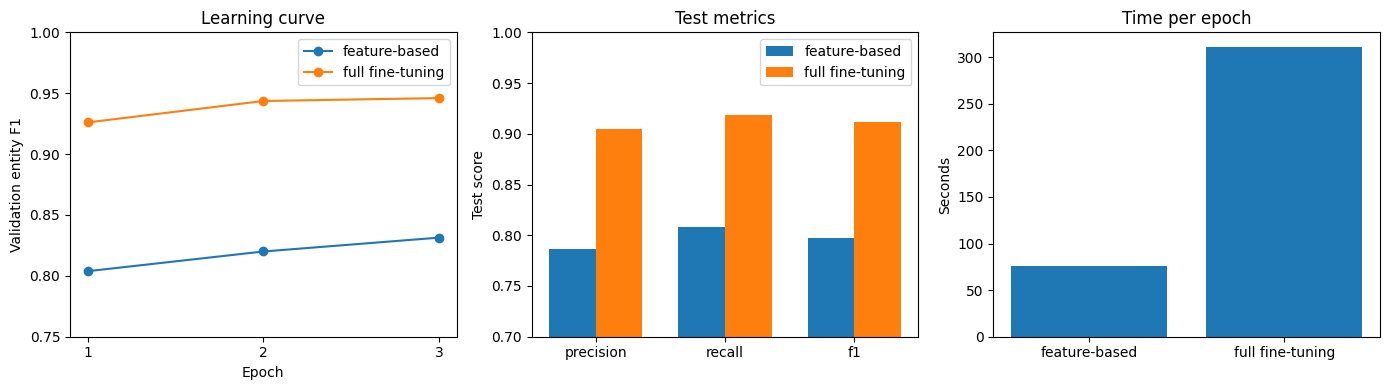

In [22]:
import matplotlib.pyplot as plt
import numpy as np

epochs = [1, 2, 3]
feature = {
    "precision": 0.7862,
    "recall": 0.8086,
    "f1": 0.7973,
    "val_f1": [0.8038, 0.8200, 0.8314],
    "val_loss": [0.1428, 0.1218, 0.1175],
    "seconds_per_epoch": 76.17,
}
full = {
    "precision": 0.9047,
    "recall": 0.9181,
    "f1": 0.9114,
    "val_f1": [0.9260, 0.9436, 0.9460],
    "val_loss": [0.0399, 0.0361, 0.0368],
    "seconds_per_epoch": 311.06,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs, feature["val_f1"], marker="o", label="feature-based")
axes[0].plot(epochs, full["val_f1"], marker="o", label="full fine-tuning")
axes[0].set_xticks(epochs)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation entity F1")
axes[0].set_title("Learning curve")
axes[0].legend()

metrics = ["precision", "recall", "f1"]
x = np.arange(len(metrics))
width = 0.36
axes[1].bar(x - width / 2, [feature[m] for m in metrics], width, label="feature-based")
axes[1].bar(x + width / 2, [full[m] for m in metrics], width, label="full fine-tuning")
axes[1].set_xticks(x, metrics)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel("Test score")
axes[1].set_title("Test metrics")
axes[1].legend()

axes[2].bar(
    ["feature-based", "full fine-tuning"],
    [feature["seconds_per_epoch"], full["seconds_per_epoch"]],
)
axes[2].set_ylabel("Seconds")
axes[2].set_title("Time per epoch")

fig.tight_layout()
plt.show()

In [24]:
import torch
from transformers import AutoModelForTokenClassification, AutoTokenizer

text = "Apple is looking at buying U.K. startup for $1 billion"

model_dir = "./models/ner-bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForTokenClassification.from_pretrained(model_dir)
model.eval()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
model.to(device)

encoded = tokenizer(text, return_tensors="pt", return_offsets_mapping=True, truncation=True)
offsets = encoded.pop("offset_mapping")[0].tolist()
encoded = {key: value.to(device) for key, value in encoded.items()}

with torch.no_grad():
    logits = model(**encoded).logits[0]
pred_ids = logits.argmax(dim=-1).tolist()

print(f"{'token':<16}{'label'}")
entities = []
for token_id, label_id, (start, end) in zip(encoded["input_ids"][0].tolist(), pred_ids, offsets):
    if start == end:
        continue
    token = text[start:end]
    id2label = {int(key): value for key, value in model.config.id2label.items()}
    label = id2label[label_id]
    print(f"{token:<16}{label}")
    if label != "O":
        entities.append((token, label))

print("entities:", entities)

token           label
Apple           B-ORG
is              O
looking         O
at              O
buying          O
U               B-LOC
.               I-LOC
K               I-LOC
.               I-LOC
start           O
up              O
for             O
$               O
1               O
billion         O
entities: [('Apple', 'B-ORG'), ('U', 'B-LOC'), ('.', 'I-LOC'), ('K', 'I-LOC'), ('.', 'I-LOC')]
